In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import os
import json

In [2]:
train_df =pd.read_csv('../data/raw/sign_mnist/sign_mnist_train.csv')
test_df =pd.read_csv('../data/raw/sign_mnist/sign_mnist_test.csv')


print("Train Shape: ", train_df.shape)
print("Test Shape: ", test_df.shape)
print("\n\nFirst Few Rows:")
train_df.head()

Train Shape:  (27455, 785)
Test Shape:  (7172, 785)


First Few Rows:


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [3]:
#Letters
label_counts = train_df['label'].value_counts().sort_index()

label_map = { i: chr(65 + i) for i in range(26) }

print("\nLabel Mapping:", label_map)
print("\nSamples Per Label:")
print(label_counts)


Label Mapping: {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G', 7: 'H', 8: 'I', 9: 'J', 10: 'K', 11: 'L', 12: 'M', 13: 'N', 14: 'O', 15: 'P', 16: 'Q', 17: 'R', 18: 'S', 19: 'T', 20: 'U', 21: 'V', 22: 'W', 23: 'X', 24: 'Y', 25: 'Z'}

Samples Per Label:
label
0     1126
1     1010
2     1144
3     1196
4      957
5     1204
6     1090
7     1013
8     1162
10    1114
11    1241
12    1055
13    1151
14    1196
15    1088
16    1279
17    1294
18    1199
19    1186
20    1161
21    1082
22    1225
23    1164
24    1118
Name: count, dtype: int64


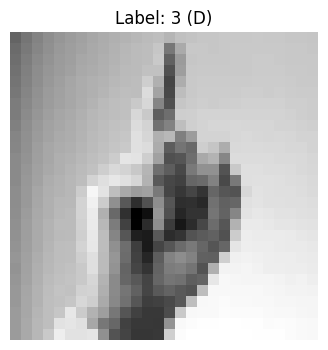

In [4]:
sample = train_df.iloc[0]
label = sample['label']
pixels = sample.drop('label').values.reshape(28, 28)


plt.figure(figsize=(4, 4))
plt.imshow(pixels, cmap='gray')
plt.title(f"Label: {label} ({label_map[label]})")
plt.axis('off')
plt.show()

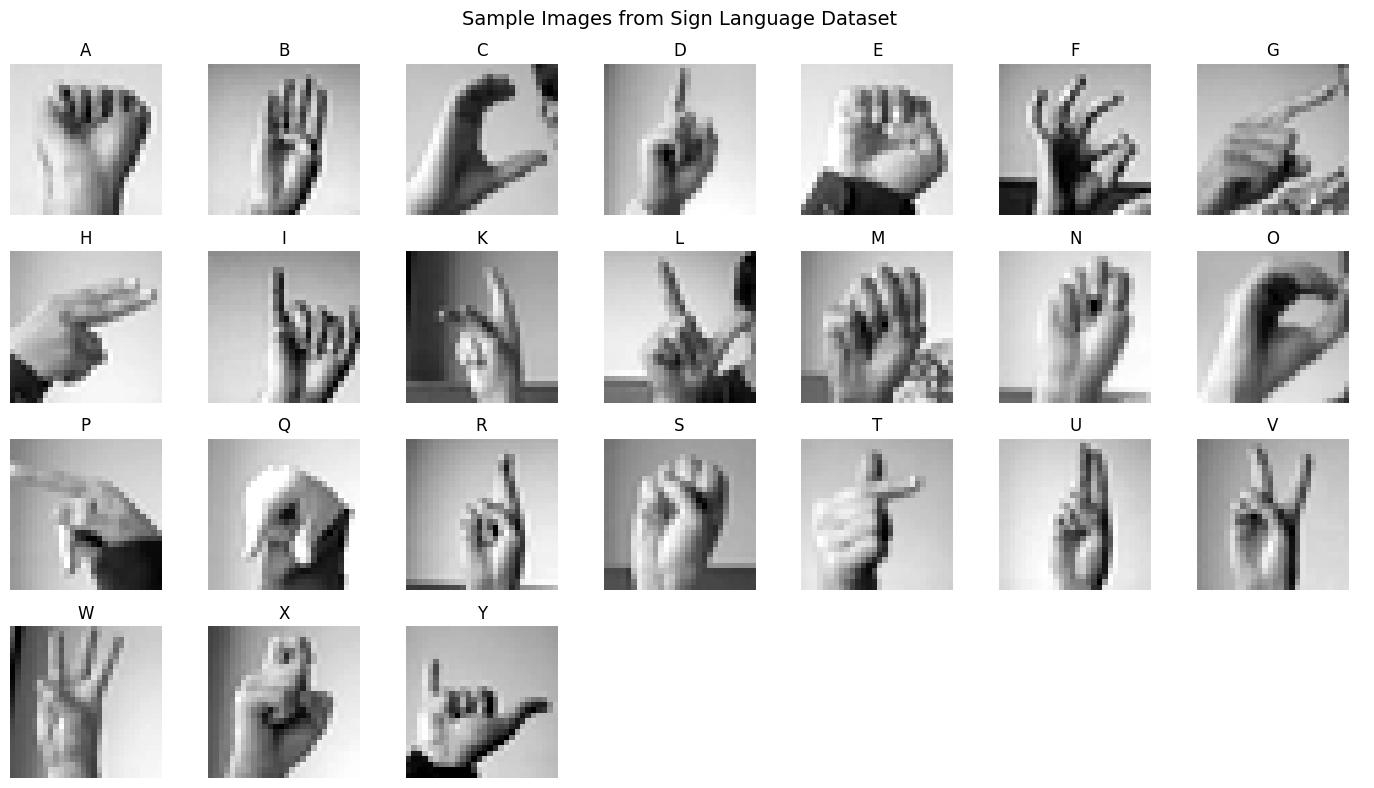

In [5]:
fig, axes = plt.subplots(4, 7, figsize=(14, 8))
axes = axes.flatten()

# Get only the labels that exist in your dataset
existing_labels = sorted(train_df['label'].unique())

for idx, ax in enumerate(axes):
    if idx >= len(existing_labels):
        ax.axis('off')
        continue
    
    label_num = existing_labels[idx]
    
    # Get first sample for this label
    label_subset = train_df[train_df['label'] == label_num]
    if len(label_subset) > 0:
        row = label_subset.iloc[0]
        pixels = row.drop('label').values.reshape(28, 28)
        
        ax.imshow(pixels, cmap='gray')
        # Check if label exists in label_map, otherwise show the number
        title = label_map.get(label_num, f"Label {label_num}")
        ax.set_title(title)
        ax.axis('off')
    else:
        ax.axis('off')

plt.suptitle('Sample Images from Sign Language Dataset', fontsize=14)
plt.tight_layout()
plt.show()

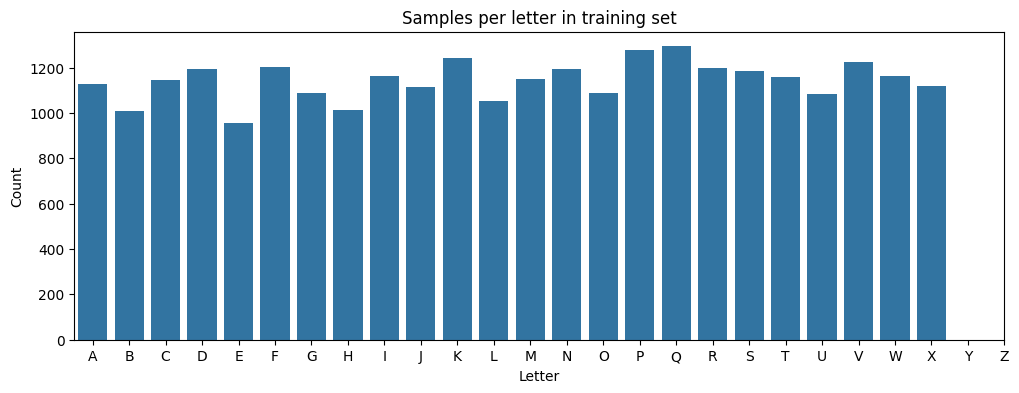

In [6]:
plt.figure(figsize=(12, 4))
sns.countplot(x='label', data=train_df)
plt.xticks(ticks=range(26), labels=[label_map[i] for i in range(26)])

plt.title('Samples per letter in training set')
plt.xlabel('Letter')
plt.ylabel('Count')
plt.show()

In [7]:
asl_dir = '../data/raw/asl_alphabet/asl_alphabet_train'

classes = sorted(os.listdir(asl_dir))
print(f"Classes found: {len(classes)}")
print(classes)

Classes found: 29
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


Image shape: (200, 200, 3)


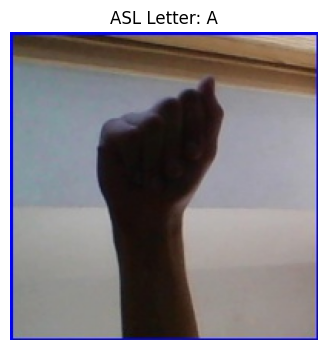

In [8]:
import cv2

sample_class = "A"
sample_folder = os.path.join(asl_dir, sample_class)
sample_image_path = os.path.join(sample_folder, os.listdir(sample_folder)[0])

img = cv2.imread(sample_image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print(f"Image shape: {img.shape}")

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title(f"ASL Letter: {sample_class}")
plt.axis('off')
plt.show()

In [9]:
class_counts = {}

for cls in classes:
    cls_path = os.path.join(asl_dir, cls)
    class_counts[cls] = len(os.listdir(cls_path))
    
counts_df = pd.DataFrame(list(class_counts.items()),columns=['class','count'])
print(counts_df)
print(f"\nTotal images: {counts_df['count'].sum()}")


      class  count
0         A   3000
1         B   3000
2         C   3000
3         D   3000
4         E   3000
5         F   3000
6         G   3000
7         H   3000
8         I   3000
9         J   3000
10        K   3000
11        L   3000
12        M   3000
13        N   3000
14        O   3000
15        P   3000
16        Q   3000
17        R   3000
18        S   3000
19        T   3000
20        U   3000
21        V   3000
22        W   3000
23        X   3000
24        Y   3000
25        Z   3000
26      del   3000
27  nothing   3000
28    space   3000

Total images: 87000


In [10]:
with open('../data/raw/wlasl/WLASL_v0.3.json', 'r') as f:
    wlasl_data = json.load(f)
    
    
print(f"Total glosses in WLASL: {len(wlasl_data)}")
print(f"\nFirst word entry:")
print(json.dumps(wlasl_data[0], indent=2))

Total glosses in WLASL: 2000

First word entry:
{
  "gloss": "book",
  "instances": [
    {
      "bbox": [
        385,
        37,
        885,
        720
      ],
      "fps": 25,
      "frame_end": -1,
      "frame_start": 1,
      "instance_id": 0,
      "signer_id": 118,
      "source": "aslbrick",
      "split": "train",
      "url": "http://aslbricks.org/New/ASL-Videos/book.mp4",
      "variation_id": 0,
      "video_id": "69241"
    },
    {
      "bbox": [
        190,
        25,
        489,
        370
      ],
      "fps": 25,
      "frame_end": -1,
      "frame_start": 1,
      "instance_id": 1,
      "signer_id": 90,
      "source": "aslsignbank",
      "split": "train",
      "url": "https://aslsignbank.haskins.yale.edu/dictionary/protected_media/glossvideo/ASL/BO/BOOK-418.mp4",
      "variation_id": 0,
      "video_id": "65225"
    },
    {
      "bbox": [
        262,
        1,
        652,
        480
      ],
      "fps": 25,
      "frame_end": -1,
      "frame_s

In [11]:
wlasl_summary = []
for entry in wlasl_data:
    wlasl_summary.append({
        'word': entry['gloss'],
        'num_videos': len(entry['instances'])
    })
    
wlasl_df = pd.DataFrame(wlasl_summary)
print(f"Total Words: {len(wlasl_df)}")
print(f"Total video instances: {wlasl_df['num_videos'].sum()}")
print(f"\nTop 20 words by video count: ")
print(wlasl_df.sort_values('num_videos', ascending=False).head(20))

Total Words: 2000
Total video instances: 21083

Top 20 words by video count: 
        word  num_videos
0       book          40
1      drink          35
2   computer          30
4      chair          26
3     before          26
5         go          26
7        who          25
6    clothes          25
8      candy          24
10      deaf          23
9     cousin          23
15      walk          22
14      thin          22
13        no          22
11      fine          22
17       yes          22
16      year          22
12      help          22
31     woman          21
25    mother          21


In [12]:
videos_dir = '../data/raw/wlasl/videos'

if os.path.exists(videos_dir):
    downloaded = os.listdir(videos_dir)
    print(f"Videos downloaded: {len(downloaded)}")
    print(f"Sample video files: {downloaded[:10]}")
else:
    print("Videos directory not found. Please run the download script to fetch WLASL videos.")

Videos downloaded: 11980
Sample video files: ['00335.mp4', '00336.mp4', '00338.mp4', '00339.mp4', '00341.mp4', '00376.mp4', '00377.mp4', '00381.mp4', '00382.mp4', '00384.mp4']
